# Rubin Jupyter + RC2 Butler Demo

This notebook verifies that:
- Jupyter runs with the `LSST (lsst_distrib)` kernel
- `lsst.daf.butler` imports correctly
- the local `rc2_subset` Butler repo is readable


In [1]:
import os
from pathlib import Path
from lsst.daf.butler import Butler

repo = Path('/Users/mjuric/projects/github.com/mjuric/rubin_install_demo/rc2/SMALL_HSC')
assert repo.exists(), f'Missing repo path: {repo}'

print('Python executable:', os.sys.executable)
print('LSST_DISTRIB_DIR:', os.environ.get('LSST_DISTRIB_DIR', '<unset>'))
print('Butler repo:', repo)

butler = Butler(str(repo))
collections = list(butler.registry.queryCollections())
print('Collections:', len(collections))
print('Has HSC/RC2/defaults:', 'HSC/RC2/defaults' in collections)
assert 'HSC/RC2/defaults' in collections

raw_query = butler.registry.queryDatasets('raw', collections='HSC/RC2/defaults')
first_raw = next(iter(raw_query.expanded()), None)
assert first_raw is not None, 'No raw datasets found in HSC/RC2/defaults'
print('Example raw dataId:', dict(first_raw.dataId.mapping))
print('Demo OK')


Python executable: /Users/mjuric/miniforge3/envs/lsst-scipipe-12.1.0/bin/python
LSST_DISTRIB_DIR: /Users/mjuric/miniforge3/envs/lsst-scipipe-12.1.0/share/eups/Darwin/lsst_distrib/g00e868bf88+d77a743519
Butler repo: /Users/mjuric/projects/github.com/mjuric/rubin_install_demo/rc2/SMALL_HSC
Collections: 56
Has HSC/RC2/defaults: True
Example raw dataId: {'instrument': 'HSC', 'detector': 41, 'exposure': 322, 'band': 'y', 'physical_filter': 'HSC-Y'}
Demo OK


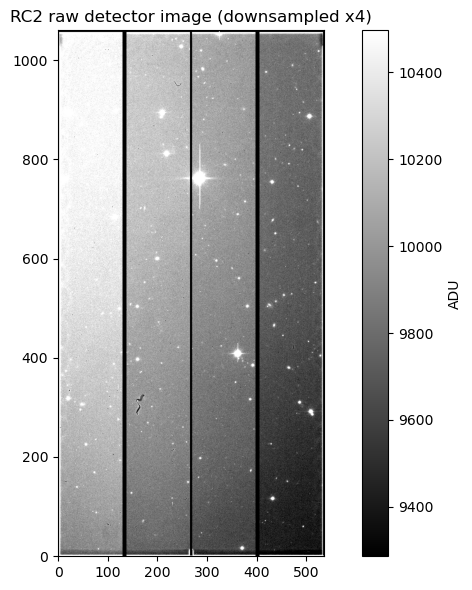

In [2]:
import numpy as np
import matplotlib.pyplot as plt

raw = butler.get(first_raw)
arr = raw.image.array
sample = arr[::4, ::4]  # downsample for faster rendering in notebook
vmin, vmax = np.percentile(sample, [5, 95])

plt.figure(figsize=(8, 6))
plt.imshow(sample, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.title('RC2 raw detector image (downsampled x4)')
plt.colorbar(label='ADU')
plt.tight_layout()
plt.show()
